In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install Pillow matplotlib numpy

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/"))

['Colab Notebooks', 'AI and Ml week 1 worksheet 0', 'niyatikayastha_workshop1.ipynb', 'Workshop-4.pdf', 'Workshop-4.gdoc', 'SumedhaMali_week5.ipynb', 'Python Assignment.docx', 'SumedhaMali_week1', 'SumedhaMali_week3 (1).ipynb', 'SumedhaMali_week4', 'Python_SumedhaMali', 'SumedhaMali_week6.ipynb', 'SumedhaMali_week7', 'Untitled document (3).gdoc', 'Assets and Tutorials Used Template.docx', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'final_submission', 'Assets and tutorials log_2408480.docx', 'Prajanya_Shrestha_2408648.zip', 'Worksheet - 0 - Essentials of Python for ML..pdf', 'Worksheet - 0 - Essentials of Python for ML..gdoc', 'SumedhaMaliweek1.ipynb', 'SumedhaMali_week0_2408480.ipynb', 'SumedhaMaliweek1 .ipynb', 'bank .csv', 'Worksheet2', 'SumedhaMali_week2.ipynb', 'SumedhaMali_week3.ipynb', 'worksheet4', 'SumedhaMali_AssignmentAI_230335', 'Copy of Engineering Project Proposal by Slidesgo.gslides', 'Tut - 07 - Solutions.pdf', '5CS021 - Assessm

Shape: (419, 236, 3)
Dtype: uint8


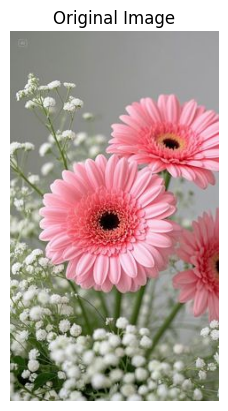

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Use the full path to your file
img = Image.open("/content/drive/MyDrive/AI and Ml week 1 worksheet 1/flower.jpg")

img_array = np.array(img)
print("Shape:", img_array.shape)
print("Dtype:", img_array.dtype)

plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

Image.open() loads the file. np.array() converts it to a 3D array of shape (height, width, 3) where the 3 channels are R, G, B. Each pixel value is 0–255.

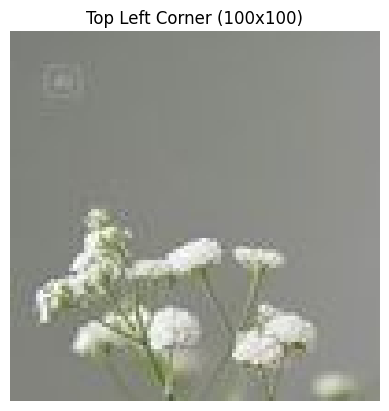

In [ ]:
#Task2
# Array slicing: [rows, columns, channels]
# Rows 0–99, Columns 0–99, all 3 channels
top_left = img_array[0:100, 0:100, :]

plt.imshow(top_left)
plt.title("Top Left Corner (100x100)")
plt.axis("off")
plt.show()

NumPy array indexing [0:100, 0:100] extracts the first 100 rows and first 100 columns — that's the top-left corner.

What's happening: img_array[:, :, 0] takes all rows and all columns but only channel index 0 (Red). The cmap parameter tells matplotlib to colorize the grayscale intensity values with a red/green/blue tint — without cmap, it would show as grayscale.

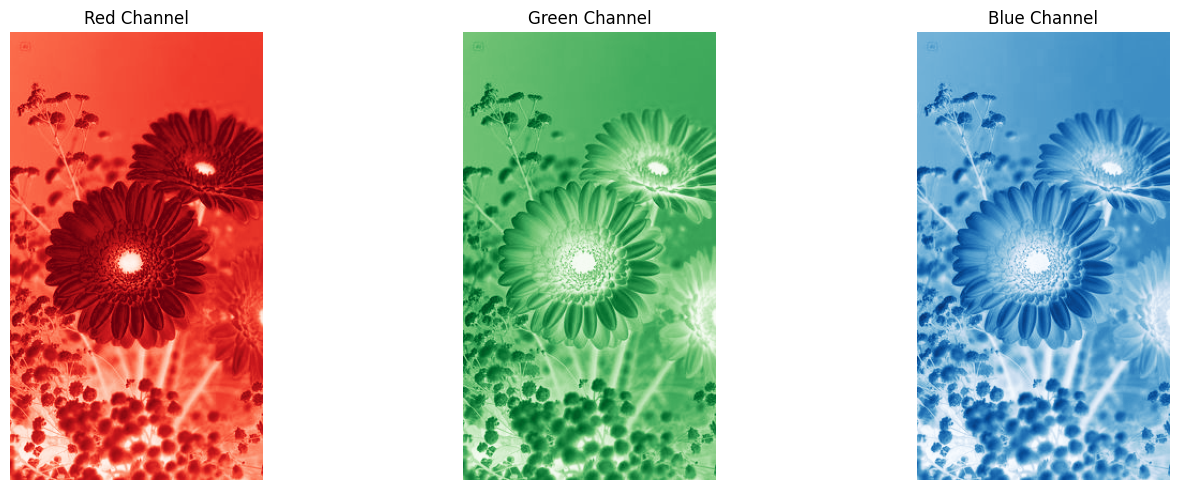

In [ ]:
#Task3
# Extract each channel using index on the 3rd axis
red_channel   = img_array[:, :, 0]   # index 0 = Red
green_channel = img_array[:, :, 1]   # index 1 = Green
blue_channel  = img_array[:, :, 2]   # index 2 = Blue

# Plot all three side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(red_channel,   cmap="Reds")
axes[0].set_title("Red Channel")
axes[0].axis("off")

axes[1].imshow(green_channel, cmap="Greens")
axes[1].set_title("Green Channel")
axes[1].axis("off")

axes[2].imshow(blue_channel,  cmap="Blues")
axes[2].set_title("Blue Channel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

What's happening: Setting all three channels (R=210, G=210, B=210) to the same value produces a neutral light gray, since equal R, G, B = gray. The .copy() is important — without it you'd modify the original img_array too.

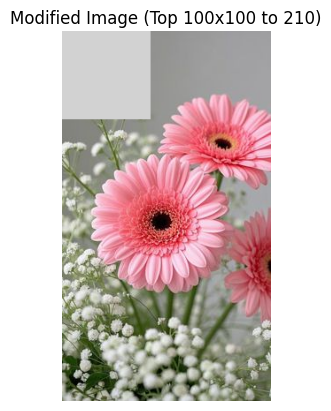

In [ ]:
#Task4
# Make a copy so the original array is not changed
modified = img_array.copy()

# Set all 3 channels of the top-left 100x100 to 210 (light gray)
modified[0:100, 0:100, :] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 to 210)")
plt.axis("off")
plt.show()

Question 2


In [ ]:
IMAGE_PATH = "/content/drive/MyDrive/AI and Ml week 1 worksheet 1/cameraman.jpg"

What's happening: .convert('L') forces the image into grayscale mode. The array is now 2D — just (height, width) — with pixel values 0 (black) to 255 (white).

Shape: (800, 1200)
Dtype: uint8


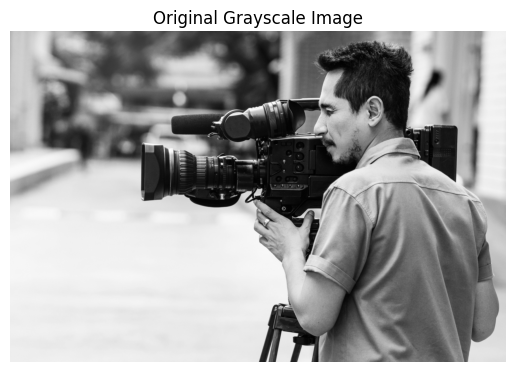

In [ ]:
#Task1
# Load as grayscale — 'L' mode means grayscale in Pillow
img = Image.open(IMAGE_PATH).convert('L')

# Convert to NumPy array
img_array = np.array(img)

print("Shape:", img_array.shape)   # (height, width) — no 3rd channel for grayscale
print("Dtype:", img_array.dtype)   # uint8

# Display
plt.imshow(img_array, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

What's happening: height // 2 gives the center row. Slicing ±75 around it gives exactly 150 pixels in each direction.

Middle section shape: (150, 150)


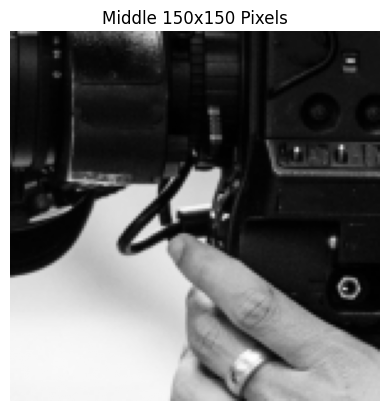

In [ ]:
#Task2
height, width = img_array.shape

# Find the center coordinates
center_row = height // 2
center_col = width  // 2

# Slice 75 pixels in each direction from center → 150x150 total
middle = img_array[center_row - 75 : center_row + 75,
                   center_col - 75 : center_col + 75]

print("Middle section shape:", middle.shape)  # (150, 150)

plt.imshow(middle, cmap='gray')
plt.title("Middle 150x150 Pixels")
plt.axis("off")
plt.show()

What's happening: This creates a binary image — every pixel is either pure black (0) or pure white (255). np.where(condition, value_if_true, value_if_false) is the cleaner way to do it.

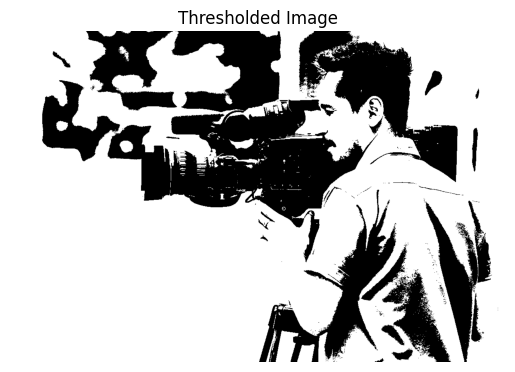

In [ ]:
#Task3
# Make a copy to avoid changing the original
thresholded = img_array.copy()

# Pixels below 100 → 0 (black), pixels >= 100 → 255 (white)
thresholded[thresholded < 100]  = 0
thresholded[thresholded >= 100] = 255

plt.imshow(thresholded, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

What's happening: Pillow's rotate() is counter-clockwise by default, so -90 gives clockwise. expand=True resizes the canvas to fit the rotated image. For NumPy, k=3 means rotate counter-clockwise 3 times = same as clockwise once.

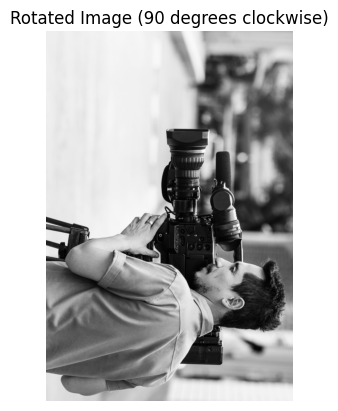

In [ ]:
#Task4
# Method 1: Using Pillow (recommended)
# Pillow's rotate is counter-clockwise by default, so use -90 or expand=True
img_rotated_pil = img.rotate(-90, expand=True)   # -90 = clockwise

plt.imshow(img_rotated_pil, cmap='gray')
plt.title("Rotated Image (90 degrees clockwise)")
plt.axis("off")
plt.show()

What's happening: An RGB image needs 3 channels. Since grayscale has equal R, G, B values, we just copy the same channel 3 times. np.stack(..., axis=-1) adds a new third axis, turning (H, W) into (H, W, 3).

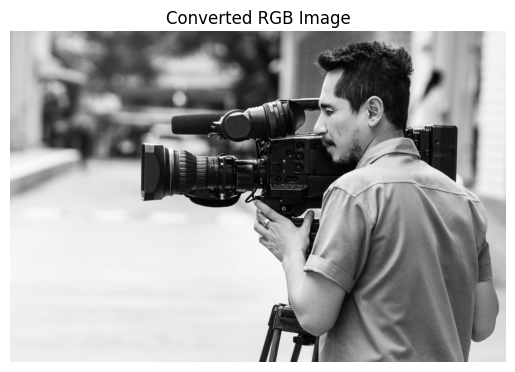

In [ ]:
#Task5
img_rgb_pil = img.convert('RGB')   # Pillow handles the conversion directly
plt.imshow(img_rgb_pil)
plt.title("Converted RGB Image")
plt.axis("off")
plt.show()

Question3


In [ ]:
#Step 1
# Load and convert to grayscale
img = Image.open("/content/drive/MyDrive/AI and Ml week 1 worksheet 1/flower.jpg").convert('L')
img_array = np.array(img, dtype=np.float64)

print("Image shape:", img_array.shape)   # (H, W)

Image shape: (419, 236)


In [ ]:
#Center (Standardize) the Data
# Each ROW is one "sample" (one row of pixels)
# Step 1: Subtract the mean of each column (feature) → centering
mean = np.mean(img_array, axis=0)          # shape: (W,) — mean of each column
centered = img_array - mean                 # broadcast: subtract from every row

print("Mean shape:", mean.shape)
print("Centered shape:", centered.shape)
print("Mean of centered (should be ~0):", np.abs(centered.mean()).round(10))

Mean shape: (236,)
Centered shape: (419, 236)
Mean of centered (should be ~0): 0.0


In [ ]:
#Calculate the Covariance Matrix
# Covariance matrix: (X^T @ X) / (n-1)
# Shape: (W, W) — covariance between every pair of pixel columns
n = centered.shape[0]                      # number of rows (samples)
cov_matrix = (centered.T @ centered) / (n - 1)

print("Covariance matrix shape:", cov_matrix.shape)   # (W, W)

Covariance matrix shape: (236, 236)


In [ ]:
#Step2 - Eigen decomposition
# Compute eigenvalues and eigenvectors from scratch using numpy's linalg
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# eigh is used for symmetric matrices (covariance is always symmetric)

# eigh returns in ASCENDING order — reverse to get descending
eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print("Eigenvalues shape:", eigenvalues.shape)    # (W,)
print("Eigenvectors shape:", eigenvectors.shape)  # (W, W)
print("Top 5 eigenvalues:", eigenvalues[:5].round(2))

Eigenvalues shape: (236,)
Eigenvectors shape: (236, 236)
Top 5 eigenvalues: [67847.7  54210.95 37899.78 27085.55 18838.55]


80% variance explained by 17 components
90% variance explained by 31 components
95% variance explained by 50 components
99% variance explained by 106 components


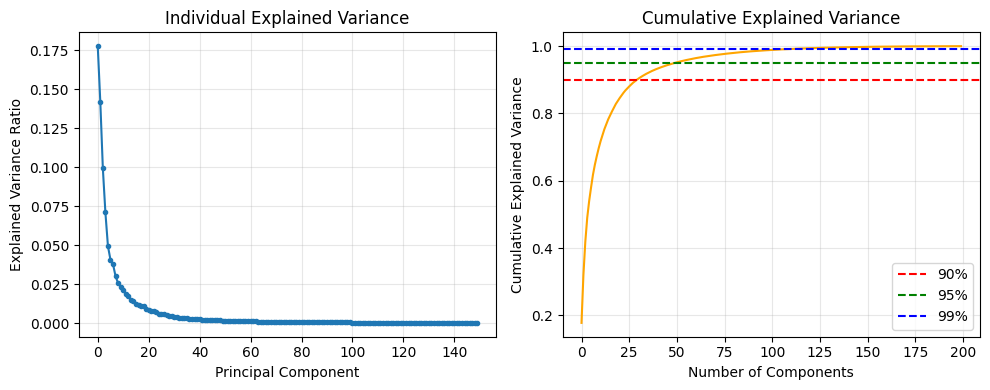

In [ ]:
#Cumulative Explained Variance Plot
# Explained variance ratio for each component
total_variance      = np.sum(eigenvalues)
explained_variance  = eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance)

# Find how many components explain 90%, 95%, 99%
for threshold in [0.80, 0.90, 0.95, 0.99]:
    k = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{int(threshold*100)}% variance explained by {k} components")

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(explained_variance[:150], marker='o', markersize=3)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Individual Explained Variance")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:200], color='orange')
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.axhline(y=0.99, color='b', linestyle='--', label='99%')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Step 3 - reconstruction function
def pca_reconstruct(centered_data, eigenvectors, mean, k):
    """
    Compress and reconstruct image using top-k principal components.

    Steps:
      1. Project data onto k eigenvectors  → lower-dim representation
      2. Project back to original space    → reconstruction
      3. Add mean back                     → undo centering
    """
    # Select top-k eigenvectors: shape (W, k)
    top_k_eigenvectors = eigenvectors[:, :k]

    # Step 1: Project — encode into k dimensions
    # centered_data: (H, W)  @  eigenvectors: (W, k)  →  scores: (H, k)
    scores = centered_data @ top_k_eigenvectors

    # Step 2: Reconstruct — decode back to W dimensions
    # scores: (H, k)  @  eigenvectors.T: (k, W)  →  reconstructed: (H, W)
    reconstructed = scores @ top_k_eigenvectors.T

    # Step 3: Add mean back
    reconstructed = reconstructed + mean

    # Clip to valid pixel range [0, 255]
    reconstructed = np.clip(reconstructed, 0, 255)

    return reconstructed.astype(np.uint8)

In [ ]:
#Step 4 - Experiment with different k vlaues
# Four different k values to compare
k_values = [10, 20, 50, 100, 150]

# Pre-compute all reconstructions
reconstructions = {}
for k in k_values:
    reconstructions[k] = pca_reconstruct(centered, eigenvectors, mean, k)
    var_explained = cumulative_variance[k-1] * 100
    print(f"k={k:4d} | Variance explained: {var_explained:.2f}%")

k=  10 | Variance explained: 69.64%
k=  20 | Variance explained: 83.70%
k=  50 | Variance explained: 95.02%
k= 100 | Variance explained: 98.84%
k= 150 | Variance explained: 99.77%


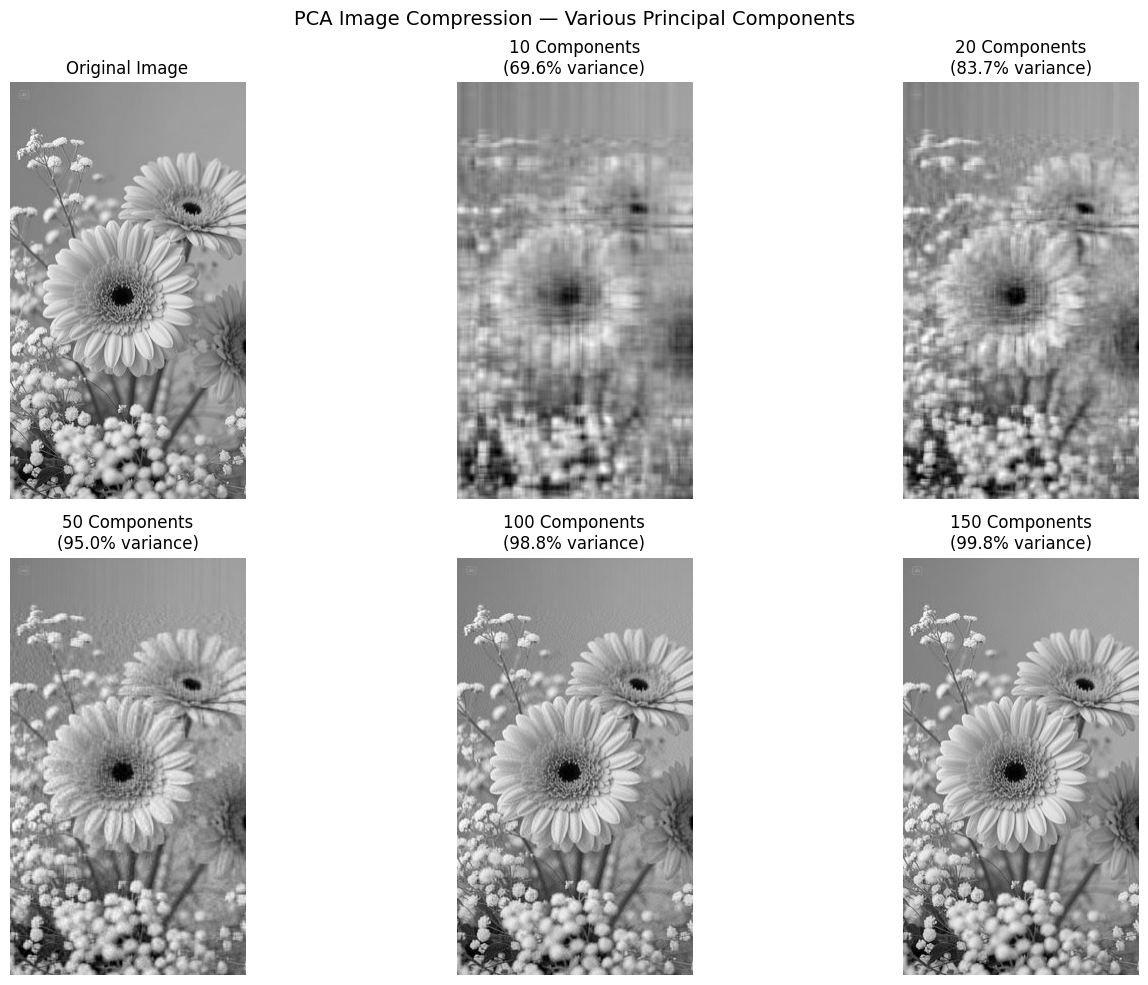

In [ ]:
#Step5 - display all results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0][0].imshow(img_array.astype(np.uint8), cmap='gray')
axes[0][0].set_title("Original Image")
axes[0][0].axis("off")

# Reconstructed images
positions = [(0,1), (0,2), (1,0), (1,1), (1,2)]
for (r, c), k in zip(positions, k_values):
    var = cumulative_variance[k-1] * 100
    axes[r][c].imshow(reconstructions[k], cmap='gray')
    axes[r][c].set_title(f"{k} Components\n({var:.1f}% variance)")
    axes[r][c].axis("off")

plt.suptitle("PCA Image Compression — Various Principal Components", fontsize=14)
plt.tight_layout()
plt.savefig("pca_compression_output.png", dpi=150)
plt.show()

In [ ]:
#Step 6 - Evaluate with MSE and PSNR
def mse(original, reconstructed):
    return np.mean((original.astype(np.float64) - reconstructed.astype(np.float64)) ** 2)

def psnr(original, reconstructed):
    error = mse(original, reconstructed)
    if error == 0:
        return float('inf')
    return 10 * np.log10(255**2 / error)

# Compression ratio = original size / compressed size
H, W = img_array.shape
original_size = H * W

print(f"\n{'k':>6} | {'Variance':>10} | {'MSE':>10} | {'PSNR (dB)':>10} | {'Compression':>12}")
print("-" * 60)
for k in k_values:
    var    = cumulative_variance[k-1] * 100
    err    = mse(img_array, reconstructions[k])
    p      = psnr(img_array, reconstructions[k])
    # Compressed size = k*(H + W + 1) numbers stored instead of H*W
    comp   = original_size / (k * (H + W + 1))
    print(f"{k:>6} | {var:>9.2f}% | {err:>10.2f} | {p:>10.2f} | {comp:>10.2f}x")



     k |   Variance |        MSE |  PSNR (dB) |  Compression
------------------------------------------------------------
    10 |     69.64% |     490.36 |      21.23 |      15.07x
    20 |     83.70% |     263.34 |      23.93 |       7.54x
    50 |     95.02% |      80.59 |      29.07 |       3.01x
   100 |     98.84% |      19.05 |      35.33 |       1.51x
   150 |     99.77% |       4.05 |      42.05 |       1.00x
